# Model Training

The objective of this notebook is to train and compare multiple machine learning models for forecasting demand 8 weeks ahead.

Since this is a time-series forecasting problem, a chronological train-test split is used to prevent data leakage and simulate real-world forecasting.

In [240]:
import warnings
warnings.filterwarnings("ignore")

import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

from sklearn.linear_model import LinearRegression, Ridge

from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import RandomizedSearchCV

from xgboost import XGBRegressor

In [241]:
df = pd.read_csv("../data/processed/final_dataset.csv")

In [242]:
print(df.shape)
df.head()

(8847, 26)


,date,demand,sku,supermarket,promotion,year,month,quarter,week_of_year,day_of_week,...,lag_56,demand_change_1,demand_change_7,rolling_mean_7,rolling_std_7,rolling_mean_14,rolling_std_14,rolling_mean_28,rolling_std_28,target
0,2019-02-26,66.0,0,0,0,2019,2,1,9,1,...,68.0,0.0,-1.0,67.714286,2.138090,68.071429,1.979288,67.571429,2.201491,71.0
1,2019-02-27,70.0,0,0,0,2019,2,1,9,2,...,68.0,4.0,-1.0,67.571429,2.225395,67.928571,2.055547,67.392857,2.114137,71.0
2,2019-02-28,70.0,0,0,0,2019,2,1,9,3,...,68.0,0.0,0.0,67.428571,1.988060,68.071429,2.129077,67.464286,2.168497,71.0
3,2019-03-01,70.0,0,0,0,2019,3,1,9,4,...,68.0,0.0,2.0,67.428571,1.988060,68.000000,2.038099,67.535714,2.219145,71.0
4,2019-03-02,67.0,0,0,0,2019,3,1,9,5,...,71.0,-3.0,0.0,67.714286,2.214670,68.285714,2.016416,67.571429,2.251396,69.0


In [243]:
# Convert date column to datetime
df["date"] = pd.to_datetime(df["date"])

In [244]:
split_date = df["date"].quantile(0.80)

train_df = df[df["date"] < split_date]

test_df = df[df["date"] >= split_date]

In [245]:
train_dates = train_df["date"].reset_index(drop=True)
test_dates = test_df["date"].reset_index(drop=True)

In [246]:
FEATURES = [
    col for col in df.columns
    if col not in ["date", "target"]
]

TARGET = "target"

X_train = train_df[FEATURES]
y_train = train_df[TARGET]

X_test = test_df[FEATURES]
y_test = test_df[TARGET]

In [247]:
print("\nTraining Shape:", X_train.shape)
print("Testing Shape :", X_test.shape)


Training Shape: (7074, 24)
Testing Shape : (1773, 24)


In [248]:
print("Training samples:", len(train_df))
print("Testing samples:", len(test_df))

print("\nTrain Date Range:")
print(train_df["date"].min(), "to", train_df["date"].max())

print("\nTest Date Range:")
print(test_df["date"].min(), "to", test_df["date"].max())

Training samples: 7074
Testing samples: 1773

Train Date Range:
2019-02-26 00:00:00 to 2021-04-21 00:00:00

Test Date Range:
2021-04-22 00:00:00 to 2021-11-04 00:00:00


In [249]:
# Baseline prediction
baseline_predictions = X_test["demand"]

In [250]:
def evaluate_model(model_name, y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    r2 = r2_score(y_true, y_pred)
    
    mape = mean_absolute_percentage_error(y_true,y_pred)

    print(model_name)

    print(f"MAE  : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R²   : {r2:.4f}")
    print(f"MAPE : {mape*100:.2f}%")
    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "MAPE": mape*100
    }

In [251]:
baseline_results = evaluate_model(
    "Baseline Model",
    y_test,
    baseline_predictions
)

Baseline Model
MAE  : 3.28
RMSE : 16.09
R²   : 0.5377
MAPE : 4.96%


In [252]:
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)

lr_results = evaluate_model(

    "Linear Regression",

    y_test,

    lr_predictions

)

Linear Regression
MAE  : 3.48
RMSE : 14.64
R²   : 0.6175
MAPE : 5.25%


In [253]:
ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train, y_train)

ridge_predictions = ridge_model.predict(X_test)

ridge_results = evaluate_model(

    "Ridge Regression",

    y_test,

    ridge_predictions

)

Ridge Regression
MAE  : 3.48
RMSE : 14.64
R²   : 0.6175
MAPE : 5.25%


In [254]:
rf_params = {

    "n_estimators": [100, 200, 300, 500],

    "max_depth": [5, 10, 15, None],

    "min_samples_split": [2, 5, 10],

    "min_samples_leaf": [1, 2, 4]

}

rf_random = RandomizedSearchCV(

    estimator=RandomForestRegressor(random_state=42),

    param_distributions=rf_params,

    n_iter=15,

    scoring="neg_root_mean_squared_error",

    cv=3,

    random_state=42,

    n_jobs=-1,

    verbose=1

)

rf_random.fit(X_train, y_train)

print("Best RF Parameters:")

print(rf_random.best_params_)

rf_model = rf_random.best_estimator_

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best RF Parameters:
{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': 15}


In [255]:
rf_predictions = rf_model.predict(X_test)

In [256]:
rf_results = evaluate_model(

    "Random Forest (Tuned)",

    y_test,

    rf_predictions

)

Random Forest (Tuned)
MAE  : 3.56
RMSE : 15.08
R²   : 0.5942
MAPE : 5.14%


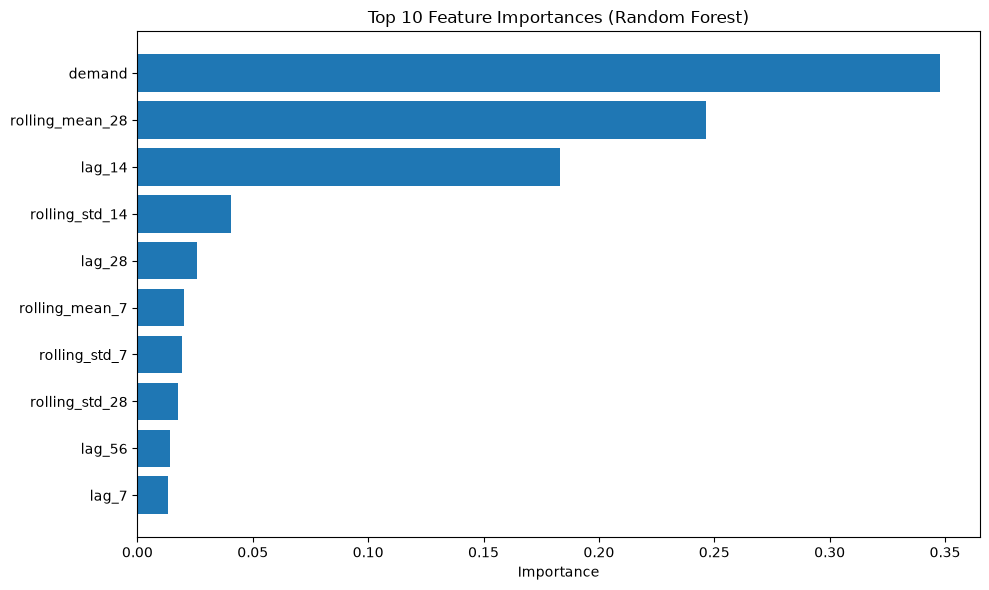

In [257]:
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"][:10],
    feature_importance["Importance"][:10]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.title("Top 10 Feature Importances (Random Forest)")

plt.tight_layout()

plt.savefig("../outputs/figures/feature_importance.png")

plt.show()

In [258]:
xgb_params = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.8, 0.9, 1.0],
    "colsample_bytree": [0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 0.1, 0.2]
}

xgb_random = RandomizedSearchCV(
    estimator=XGBRegressor(
        objective="reg:squarederror",
        random_state=42
    ),
    param_distributions=xgb_params,
    n_iter=15,
    scoring="neg_root_mean_squared_error",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_random.fit(X_train, y_train)

print("Best XGBoost Parameters:")
print(xgb_random.best_params_)

xgb_model = xgb_random.best_estimator_

xgb_predictions = xgb_model.predict(X_test)

xgb_results = evaluate_model(
    "XGBoost (Tuned)",
    y_test,
    xgb_predictions
)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best XGBoost Parameters:
{'subsample': 1.0, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0.2, 'colsample_bytree': 0.8}
XGBoost (Tuned)
MAE  : 3.18
RMSE : 14.66
R²   : 0.6166
MAPE : 4.73%


In [259]:
comparison = pd.DataFrame([
    baseline_results,
    lr_results,
    ridge_results,
    rf_results,
    xgb_results
])

comparison

,Model,MAE,RMSE,R2,MAPE
0,Baseline Model,3.284602,16.093839,0.537750,4.963328
1,Linear Regression,3.476185,14.639462,0.617521,5.247065
2,Ridge Regression,3.475467,14.638982,0.617546,5.245945
3,Random Forest (Tuned),3.562329,15.078864,0.594216,5.142295
4,XGBoost (Tuned),3.180711,14.656746,0.616617,4.725909


In [260]:
# Sort models based on RMSE (Primary Evaluation Metric)
comparison = comparison.sort_values(by="RMSE").reset_index(drop=True)

# Add Ranking
comparison.index = comparison.index + 1
comparison.index.name = "Rank"

# Display comparison table with highlighted best metrics
display(
    comparison.style
    .format({
        "MAE": "{:.3f}",
        "RMSE": "{:.3f}",
        "R2": "{:.3f}",
        "MAPE": "{:.2f}%"
    })
    .highlight_min(subset=["MAE", "RMSE", "MAPE"], color="#c8e6c9")
    .highlight_max(subset=["R2"], color="#c8e6c9")
)

# Display the selected model
best_model = comparison.iloc[0]

print("-" * 60)
print(" Final Selected Model")
print("-" * 60)
print(f"Model : {best_model['Model']}")
print(f"RMSE  : {best_model['RMSE']:.3f}")
print(f"R²    : {best_model['R2']:.3f}")
print(f"MAE   : {best_model['MAE']:.3f}")
print(f"MAPE  : {best_model['MAPE']:.2f}%")
print("-" * 60)

,Model,MAE,RMSE,R2,MAPE
Rank,,,,,
1,Ridge Regression,3.475,14.639,0.618,5.25%
2,Linear Regression,3.476,14.639,0.618,5.25%
3,XGBoost (Tuned),3.181,14.657,0.617,4.73%
4,Random Forest (Tuned),3.562,15.079,0.594,5.14%
5,Baseline Model,3.285,16.094,0.538,4.96%


------------------------------------------------------------
 Final Selected Model
------------------------------------------------------------
Model : Ridge Regression
RMSE  : 14.639
R²    : 0.618
MAE   : 3.475
MAPE  : 5.25%
------------------------------------------------------------


### Final Model Selection

Five forecasting models were evaluated using MAE, RMSE, MAPE, and R².

Although the tuned XGBoost model achieved the lowest MAE and MAPE, Ridge Regression achieved the lowest RMSE and the highest R² score.

Since demand forecasting is more sensitive to large prediction errors that may result in stock-outs or excess inventory, RMSE was selected as the primary evaluation metric. Based on this criterion, Ridge Regression was selected as the final forecasting model.

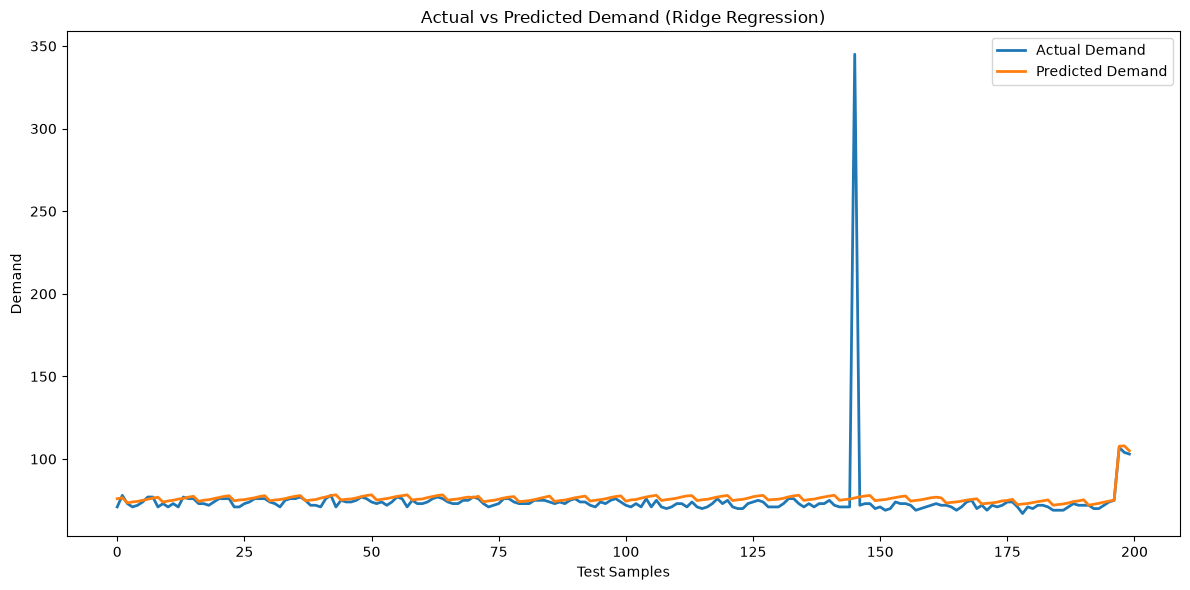

In [261]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    y_test.values[:200],
    label="Actual Demand",
    linewidth=2
)

plt.plot(
    ridge_predictions[:200],
    label="Predicted Demand",
    linewidth=2
)

plt.title("Actual vs Predicted Demand (Ridge Regression)")
plt.xlabel("Test Samples")
plt.ylabel("Demand")

plt.legend()

plt.tight_layout()

plt.savefig("../outputs/figures/forecast_vs_actual.png")

plt.show()

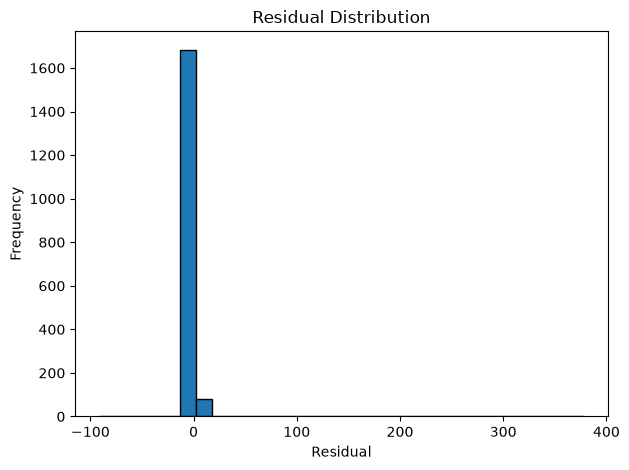

In [262]:
residuals = y_test - ridge_predictions
plt.hist(
    residuals,
    bins=30,
    edgecolor="black"
)

plt.title("Residual Distribution")

plt.xlabel("Residual")

plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig("../outputs/figures/residual_distribution.png")

plt.show()

In [263]:
import pickle

with open("../models/best_model.pkl", "wb") as file:
    pickle.dump(ridge_model, file)

print("Best model saved successfully!")

Best model saved successfully!


# **Model Training Summary**

The objective of this notebook was to develop and evaluate machine learning models capable of forecasting product demand eight weeks in advance for each supermarket–SKU combination. To ensure a realistic forecasting scenario, the dataset was divided using a chronological train-test split, preventing temporal data leakage and allowing the models to be evaluated on future observations.

A persistence baseline was established as a benchmark before training four machine learning models: Linear Regression, Ridge Regression, Random Forest, and XGBoost. Hyperparameter optimization for the tree-based models was performed using RandomizedSearchCV to identify parameter combinations that provided the best generalization performance.

Model performance was assessed using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), Mean Absolute Percentage Error (MAPE), and the Coefficient of Determination (R²). Since demand forecasting directly impacts inventory planning, RMSE was selected as the primary evaluation metric because it penalizes large prediction errors that can lead to stock-outs or excess inventory.

Among the evaluated approaches, Ridge Regression achieved the lowest RMSE and the highest R² score, while the tuned XGBoost model produced the lowest MAE and MAPE. As the difference between these models was marginal, Ridge Regression was selected as the final forecasting model due to its superior RMSE, simpler implementation, and strong generalization performance.

Overall, the developed forecasting pipeline demonstrates a complete end-to-end machine learning workflow, encompassing data preprocessing, feature engineering, model development, hyperparameter optimization, performance evaluation, and model selection. The resulting model provides a reliable foundation for supporting data-driven demand planning and inventory management decisions.

## Generate Forecast File

In [264]:
import joblib

# Load trained model
best_model = joblib.load("../models/best_model.pkl")

# Generate forecasts
forecast_predictions = best_model.predict(X_test)

# Load encoders
sku_encoder = joblib.load("../models/sku_encoder.pkl")
supermarket_encoder = joblib.load("../models/supermarket_encoder.pkl")

# Create forecast dataframe
forecast_df = pd.DataFrame({
    "Date": test_df["date"].reset_index(drop=True),
    "SKU": test_df["sku"].reset_index(drop=True),
    "Supermarket": test_df["supermarket"].reset_index(drop=True),
    "Actual Demand": y_test.reset_index(drop=True),
    "Forecasted Demand": forecast_predictions.round(2)
})

# Decode categorical values
forecast_df["SKU"] = sku_encoder.inverse_transform(forecast_df["SKU"])
forecast_df["Supermarket"] = supermarket_encoder.inverse_transform(
    forecast_df["Supermarket"]
)

# Forecast Error
forecast_df["Forecast Error"] = (
    forecast_df["Actual Demand"] -
    forecast_df["Forecasted Demand"]
).round(2)

# Absolute Error
forecast_df["Absolute Error"] = (
    forecast_df["Forecast Error"]
    .abs()
)

# Display sample forecasts
forecast_df.head()

,Date,SKU,Supermarket,Actual Demand,Forecasted Demand,Forecast Error,Absolute Error
0,2021-04-22,Free Range Eggs,DailyNeeds,71.0,75.98,-4.98,4.98
1,2021-04-23,Free Range Eggs,DailyNeeds,78.0,76.53,1.47,1.47
2,2021-04-24,Free Range Eggs,DailyNeeds,73.0,73.47,-0.47,0.47
3,2021-04-25,Free Range Eggs,DailyNeeds,71.0,74.02,-3.02,3.02
4,2021-04-26,Free Range Eggs,DailyNeeds,72.0,74.34,-2.34,2.34


In [ ]:
import os
import joblib
import numpy as np
import pandas as pd

# Generate Demand Forecasts Using the Final Selected Model

# Load trained model and label encoders
best_model = joblib.load("../models/best_model.pkl")
sku_encoder = joblib.load("../models/sku_encoder.pkl")
supermarket_encoder = joblib.load("../models/supermarket_encoder.pkl")

# Generate demand forecasts
forecast_predictions = best_model.predict(X_test)

# Demand cannot be negative
forecast_predictions = np.maximum(forecast_predictions, 0)

# Create forecast dataframe
forecast_df = pd.DataFrame({
    "Date": test_df["date"].values,
    "Supermarket": supermarket_encoder.inverse_transform(test_df["supermarket"]),
    "SKU": sku_encoder.inverse_transform(test_df["sku"]),
    "Actual Demand": y_test.values,
    "Forecasted Demand": np.round(forecast_predictions, 2)
})

# Calculate forecasting errors
forecast_df["Forecast Error"] = (
    forecast_df["Actual Demand"] -
    forecast_df["Forecasted Demand"]
).round(2)

forecast_df["Absolute Error"] = (
    forecast_df["Forecast Error"].abs()
)

# Sort for easier analysis
forecast_df.sort_values(
    by=["Date", "Supermarket", "SKU"],
    inplace=True
)

forecast_df.reset_index(drop=True, inplace=True)

# Save forecast file
os.makedirs("../outputs/predictions", exist_ok=True)

forecast_path = "../outputs/predictions/forecast.csv"

forecast_df.to_csv(
    forecast_path,
    index=False
)

# Display summary
print("-" * 60)
print("Forecast Generation Completed Successfully")
print("-" * 60)
print(f"Total Forecasts Generated : {len(forecast_df)}")
print(f"Forecast File Saved To    : {forecast_path}")
print("-" * 60)

forecast_df.head(10)

------------------------------------------------------------
Forecast Generation Completed Successfully
------------------------------------------------------------
Total Forecasts Generated : 1773
Forecast File Saved To    : ../outputs/predictions/forecast.csv
------------------------------------------------------------


,Date,Supermarket,SKU,Actual Demand,Forecasted Demand,Forecast Error,Absolute Error
0,2021-04-22,DailyNeeds,Free Range Eggs,71.0,75.98,-4.98,4.98
1,2021-04-22,DailyNeeds,Organic Milk,107.0,107.70,-0.70,0.70
2,2021-04-22,DailyNeeds,Whole Wheat Bread,63.0,62.57,0.43,0.43
3,2021-04-22,FreshMart,Free Range Eggs,70.0,66.45,3.55,3.55
4,2021-04-22,FreshMart,Organic Milk,108.0,102.25,5.75,5.75
5,2021-04-22,FreshMart,Whole Wheat Bread,58.0,58.75,-0.75,0.75
6,2021-04-22,GreenBasket,Free Range Eggs,77.0,78.32,-1.32,1.32
7,2021-04-22,GreenBasket,Organic Milk,58.0,56.33,1.67,1.67
8,2021-04-22,GreenBasket,Whole Wheat Bread,96.0,96.91,-0.91,0.91
9,2021-04-23,DailyNeeds,Free Range Eggs,78.0,76.53,1.47,1.47
